# Final Model Evaluation

> **Prerequisite:** Run `clean_data.ipynb` first. This notebook reads from `cleaned_data/`.

Fits two Cox PH models (with and without PGS), reports their concordance indices with 95% CIs, and plots a forest-style comparison against the external **PANGEA** benchmark (MGUS patient at 1st visit, no BM).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.utils import resample

## Load data

In [2]:
for p in ['cleaned_data/mm_pgs_score.csv', 'cleaned_data/mm_nopgs.csv', 'cleaned_data/mm_pgs_bin.csv']:
    assert Path(p).exists(), f'{p} not found — run clean_data.ipynb first.'

df_pgs    = pd.read_csv('cleaned_data/mm_pgs_score.csv', index_col='ID')
df_nopgs  = pd.read_csv('cleaned_data/mm_nopgs.csv',     index_col='ID')
df_pgsbin = pd.read_csv('cleaned_data/mm_pgs_bin.csv',   index_col='ID')

print(f'PGS dataset:     {len(df_pgs)} rows,    columns: {list(df_pgs.columns)}')
print(f'No-PGS dataset:  {len(df_nopgs)} rows,  columns: {list(df_nopgs.columns)}')
print(f'PGS-bin dataset: {len(df_pgsbin)} rows, columns: {list(df_pgsbin.columns)}')

PGS dataset:     2000 rows,    columns: ['ancestry', 'age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_score', 'status', 'time_years']
No-PGS dataset:  2000 rows,  columns: ['ancestry', 'age', 'm_spike', 'sflc_ratio', 'creatinine', 'status', 'time_years']
PGS-bin dataset: 2000 rows, columns: ['ancestry', 'age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_bin', 'status', 'time_years']


## Fit Cox PH models

In [3]:
features_pgs    = ['age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_score']
features_nopgs  = ['age', 'm_spike', 'sflc_ratio', 'creatinine']
features_pgsbin = ['age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_bin']

cox_pgs = CoxPHFitter()
cox_pgs.fit(df_pgs[features_pgs + ['time_years', 'status']],
            duration_col='time_years', event_col='status')

cox_nopgs = CoxPHFitter()
cox_nopgs.fit(df_nopgs[features_nopgs + ['time_years', 'status']],
              duration_col='time_years', event_col='status')

cox_pgsbin = CoxPHFitter()
cox_pgsbin.fit(df_pgsbin[features_pgsbin + ['time_years', 'status']],
               duration_col='time_years', event_col='status')

print(f'C-index    (PGS score): {cox_pgs.concordance_index_:.4f}')
print(f'C-index      (PGS bin): {cox_pgsbin.concordance_index_:.4f}')
print(f'C-index       (no PGS): {cox_nopgs.concordance_index_:.4f}')

C-index    (PGS score): 0.7080
C-index      (PGS bin): 0.7055
C-index       (no PGS): 0.6895


## Bootstrap 95% CIs for the concordance index

Lifelines does not provide analytical CIs for the C-index, so we bootstrap (1000 resamples).

**Important:** each bootstrap iteration fits on a resample but evaluates C-index on the **original data**. Evaluating in-sample on the bootstrap data (the naive approach) produces artificially low C-indices (~0.5) because duplicate rows get identical risk scores — tied predicted values are counted as 0.5-concordant per pair, swamping the calculation as ~37% of rows are duplicates on average.

In [4]:
def bootstrap_cindex(df, features, n_boot=10, seed=42):
    rng = np.random.default_rng(seed)
    c_stats = []
    for _ in range(n_boot):
        sample = df.sample(n=len(df), replace=True, random_state=int(rng.integers(1e9)))
        try:
            cox = CoxPHFitter()
            cox.fit(sample[features + ['time_years', 'status']],
                    duration_col='time_years', event_col='status')
            risk_scores = cox.predict_partial_hazard(df[features])
            c = concordance_index(df['time_years'], -risk_scores, df['status'])
            c_stats.append(c)
        except Exception:
            pass
    return np.percentile(c_stats, [2.5, 97.5])

print('Bootstrapping PGS score model...')
ci_pgs    = bootstrap_cindex(df_pgs,    features_pgs)
print(f'  95% CI: {ci_pgs[0]:.3f}–{ci_pgs[1]:.3f}')

print('Bootstrapping PGS bin model...')
ci_pgsbin = bootstrap_cindex(df_pgsbin, features_pgsbin)
print(f'  95% CI: {ci_pgsbin[0]:.3f}–{ci_pgsbin[1]:.3f}')

print('Bootstrapping no-PGS model...')
ci_nopgs  = bootstrap_cindex(df_nopgs,  features_nopgs)
print(f'  95% CI: {ci_nopgs[0]:.3f}–{ci_nopgs[1]:.3f}')

Bootstrapping PGS score model...
  95% CI: 0.702–0.714
Bootstrapping PGS bin model...
  95% CI: 0.698–0.713
Bootstrapping no-PGS model...
  95% CI: 0.684–0.698


## K-fold cross-validation — bias-corrected C-index

The in-sample C-index is optimistically biased (model evaluated on its own training data).
K-fold CV fits on k−1 folds and evaluates on the held-out fold, giving an out-of-sample estimate.
The CV mean becomes the reported point estimate; the bootstrap CIs above are wide enough to remain valid around it.

In [5]:
from sklearn.model_selection import KFold

def cv_cindex(df, features, k=5, seed=42):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    fold_scores = []
    for train_idx, test_idx in kf.split(df):
        train, test = df.iloc[train_idx], df.iloc[test_idx]
        cox = CoxPHFitter()
        cox.fit(train[features + ['time_years', 'status']],
                duration_col='time_years', event_col='status')
        risk_scores = cox.predict_partial_hazard(test[features])
        c = concordance_index(test['time_years'], -risk_scores, test['status'])
        fold_scores.append(c)
    return np.mean(fold_scores), fold_scores

cv_pgs,    folds_pgs    = cv_cindex(df_pgs,    features_pgs)
cv_pgsbin, folds_pgsbin = cv_cindex(df_pgsbin, features_pgsbin)
cv_nopgs,  folds_nopgs  = cv_cindex(df_nopgs,  features_nopgs)

print(f'CV C-index (PGS score): {cv_pgs:.4f}    optimism: {cox_pgs.concordance_index_ - cv_pgs:+.4f}')
print(f'CV C-index   (PGS bin): {cv_pgsbin:.4f}  optimism: {cox_pgsbin.concordance_index_ - cv_pgsbin:+.4f}')
print(f'CV C-index    (no PGS): {cv_nopgs:.4f}  optimism: {cox_nopgs.concordance_index_ - cv_nopgs:+.4f}')

CV C-index (PGS score): 0.7088    optimism: -0.0008
CV C-index   (PGS bin): 0.7062  optimism: -0.0007
CV C-index    (no PGS): 0.6898  optimism: -0.0003


## C-index comparison — forest plot

PANGEA benchmark: MGUS patient at 1st visit, no bone marrow biopsy.  
C-statistic: **0.879 (0.586–0.938)** (externally reported).

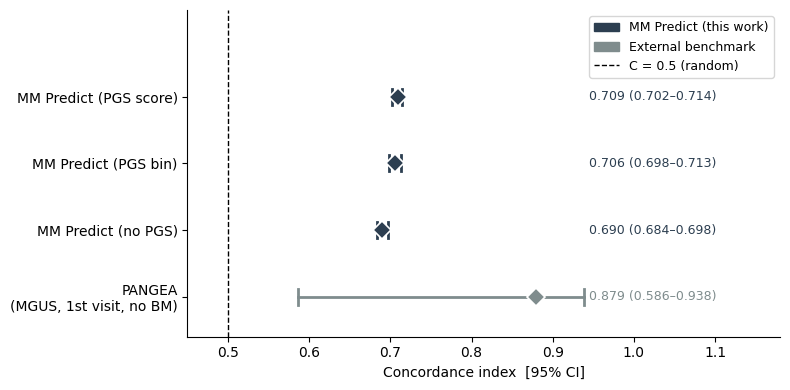

In [6]:
models = [
    {
        'label':    'PANGEA\n(MGUS, 1st visit, no BM)',
        'c':         0.879,
        'lo':        0.586,
        'hi':        0.938,
        'external':  True,
    },
    {
        'label':    'MM Predict (no PGS)',
        'c':         cv_nopgs,
        'lo':        ci_nopgs[0],
        'hi':        ci_nopgs[1],
        'external':  False,
    },
    {
        'label':    'MM Predict (PGS bin)',
        'c':         cv_pgsbin,
        'lo':        ci_pgsbin[0],
        'hi':        ci_pgsbin[1],
        'external':  False,
    },
    {
        'label':    'MM Predict (PGS score)',
        'c':         cv_pgs,
        'lo':        ci_pgs[0],
        'hi':        ci_pgs[1],
        'external':  False,
    },
]

OUR_COLOR = '#2c3e50'
EXT_COLOR = '#7f8c8d'

fig, ax = plt.subplots(figsize=(8, 4.0))

for i, m in enumerate(models):
    color = EXT_COLOR if m['external'] else OUR_COLOR
    lo, hi, c = m['lo'], m['hi'], m['c']

    ax.plot([lo, hi], [i, i], color=color, linewidth=2, zorder=2)
    ax.plot([lo, lo], [i - 0.12, i + 0.12], color=color, linewidth=2, zorder=2)
    ax.plot([hi, hi], [i - 0.12, i + 0.12], color=color, linewidth=2, zorder=2)
    ax.plot(c, i, 'D', color=color, markersize=9, zorder=3,
            markeredgecolor='white', markeredgewidth=1.2)

    ax.text(
        0.945, i,
        f'{c:.3f} ({lo:.3f}–{hi:.3f})',
        va='center', ha='left', fontsize=9, color=color
    )

ref_line = ax.axvline(x=0.5, color='black', linewidth=1, linestyle='--', label='C = 0.5 (random)')

ax.set_yticks(range(len(models)))
ax.set_yticklabels([m['label'] for m in models], fontsize=10)
ax.set_xlabel('Concordance index  [95% CI]', fontsize=10)
ax.set_xlim(0.45, 1.18)
ax.set_ylim(-0.6, len(models) + 0.3)
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    mpatches.Patch(color=OUR_COLOR, label='MM Predict (this work)'),
    mpatches.Patch(color=EXT_COLOR, label='External benchmark'),
    ref_line,
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')

plt.savefig("img/c_indices_vs_pangea.svg")
plt.tight_layout()
plt.show()

## Summary table

In [7]:
rows = []
for m in reversed(models):
    rows.append({
        'Model':   m['label'].replace('\n', ' '),
        'C-index': round(m['c'],  3),
        'CI lower': round(m['lo'], 3),
        'CI upper': round(m['hi'], 3),
    })
pd.DataFrame(rows)

,Model,C-index,CI lower,CI upper
0,MM Predict (PGS score),0.709,0.702,0.714
1,MM Predict (PGS bin),0.706,0.698,0.713
2,MM Predict (no PGS),0.690,0.684,0.698
3,"PANGEA (MGUS, 1st visit, no BM)",0.879,0.586,0.938
